# Design of Experiments

## Context
In many experimental systems, multiple variables influence an outcome simultaneously. When the number of variables grows, designing experiments that are both informative and feasible becomes nontrivial.

In this practical, you will explore how experimental design choices affect what can (and cannot) be learned from data, using a simplified simulated system.

## Questions

You are studying a production process influenced by controllable factors. The goal is to understand how experimental design choices affect what can be learned from data.

You start with a system controlled by two factors, A and B.

1. You want to understand how the output depends on A and B, including possible combined effects. Describe how you would choose which measurements to perform so that these effects could be identified.

You are now given a simulated response *y1* (formula given below).

2. Make a **surface plot** of *y1* for all values of A and B between −1 and 1.

You are now given a different simulated response *y′* (formula given below).

3. Make a **heatmap** of *y2* for all values of A and B between −1 and 1.

4. Based on these visualizations, describe how A and B affect *y1* and *y2*. 



You now consider a system with seven controllable factors A, B, C, D, E, F, and G. Each factor can take two levels, encoded as −1 and +1.

5. How does increasing the number of factors from 2 to 7 affect the number of experiments required to capture all individual and combined effects?

6. A full two-level factorial design is a design in which every factor is tested at both levels (−1 and +1) in all possible combinations. Using **pyDOE** (or **pyDOE2**), generate the full two-level factorial design for seven factors. Report the shape of the design matrix and show the first 7 and last 7 rows.

Suppose you are only allowed to run 16 experiments.

7. Randomly select 16 rows from the full matrix. Repeat this random selection twice to obtain different reduced designs. Visualize each reduced design as a table and discuss whether all designs are equally informative. What information is missing in each case?

You are now given a response *y3* (formula given below).

8. For each factor, plot the response *y3* at the two levels −1 and +1 using one of the reduced designs. What can you infer about the importance of each factor? How does this influence how you would design the next set of experiments?

9. Using scipy, perform a one-way ANOVA for each factor (comparing the response at −1 versus +1). Report the p-values and compare your statistical conclusions with your visual conclusions from Question 8.

10. From the seven-factor system, construct two contour plots that you consider useful for understanding the behavior of the response. You must clearly state which two factors are shown on the axes, how the remaining five factors are fixed, and justify why this visualization provides meaningful insight into the system.


y1 = 2A - 3B\
y2 = 4AB +0.5A\
y3 = 3A - 2C + 0.2D - 0.01F/E + noise

In [12]:
# Setup (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D plots)
from IPython.display import display, Markdown
from scipy import stats

np.random.seed(0)

# Factor names used in the 7-factor design
factors = ['A','B','C','D','E','F','G']


**1. Experimental plan for identifying main + combined effects (A, B):**  
Use a two-level full factorial design with the four corner points: (-1,-1),(-1,+1),(+1,-1),(+1,+1).  
This allows you to estimate the effects of A and B and AB.  

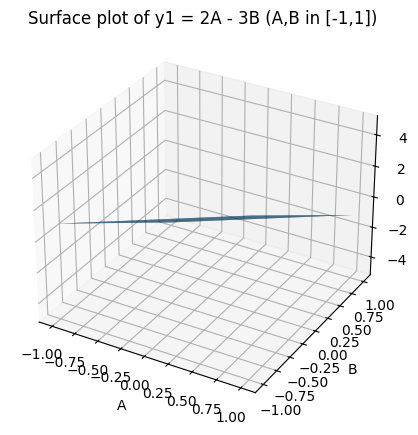

In [13]:
# Q2
# y1 = 2A - 3B
A = np.linspace(-1, 1, 101)
B = np.linspace(-1, 1, 101)
AA, BB = np.meshgrid(A, B)
y1 = 2*AA - 3*BB

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(AA, BB, y1, rstride=1, cstride=1, linewidth=0, antialiased=True)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('y1')
ax.set_title('Surface plot of y1 = 2A - 3B (A,B in [-1,1])')
plt.show()


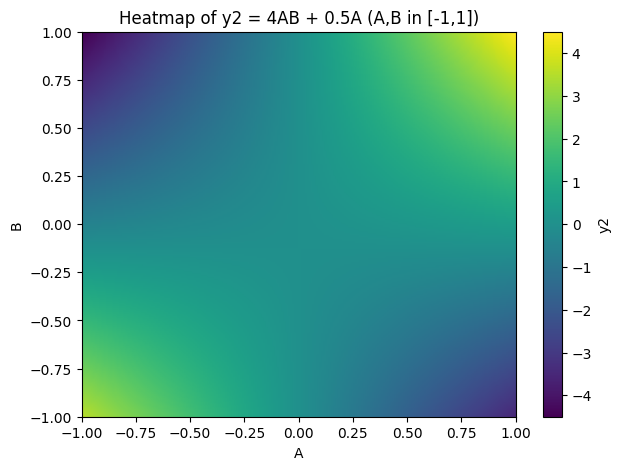

In [14]:
# Q3
# y2 = 4AB + 0.5A
A = np.linspace(-1, 1, 201)
B = np.linspace(-1, 1, 201)
AA, BB = np.meshgrid(A, B)
y2 = 4*AA*BB + 0.5*AA

plt.figure(figsize=(7,5))
im = plt.imshow(y2, origin='lower', extent=[-1,1,-1,1], aspect='auto')
plt.xlabel('A')
plt.ylabel('B')
plt.title('Heatmap of y2 = 4AB + 0.5A (A,B in [-1,1])')
plt.colorbar(im, label='y2')
plt.show()


**4. How A and B affect the responses:**  
- y1 = 2A − 3B is a plane: it increases linearly with A (slope +2) and decreases linearly with B (slope −3). There is no interaction between A and B.  
- y2 = 4AB + 0.5A includes an interaction term (AB): the effect of A depends on the sign/value of B (and vice versa). The 0.5A term adds a smaller main effect of A.

**5. Effect of increasing factors from 2 to 7:**  

Factorial design requires 2^k experiments, meaning that for k = 2, there will be 4 runs. For k = 7, there will be 128, and it increases exponentially with higher k's.

In [16]:
# Q6
# pyDOE/pyDOE2 is not installed here, so we generate the same 2-level full factorial design
# that pyDOE2.ff2n(7) would produce: all combinations of -1/+1 for 7 factors.

import itertools
full_design = np.array(list(itertools.product([-1, 1], repeat=7)))
df_full = pd.DataFrame(full_design, columns=factors)

display(Markdown(f"""**6. Full two-level factorial design (7 factors):**  
Design matrix shape: **{df_full.shape}**"""))

display(Markdown("""First 7 rows:"""))
display(df_full.head(7))

display(Markdown("""Last 7 rows:"""))
display(df_full.tail(7))


**6. Full two-level factorial design (7 factors):**  
Design matrix shape: **(128, 7)**

First 7 rows:

,A,B,C,D,E,F,G
0,-1,-1,-1,-1,-1,-1,-1
1,-1,-1,-1,-1,-1,-1,1
2,-1,-1,-1,-1,-1,1,-1
3,-1,-1,-1,-1,-1,1,1
4,-1,-1,-1,-1,1,-1,-1
5,-1,-1,-1,-1,1,-1,1
6,-1,-1,-1,-1,1,1,-1


Last 7 rows:

,A,B,C,D,E,F,G
121,1,1,1,1,-1,-1,1
122,1,1,1,1,-1,1,-1
123,1,1,1,1,-1,1,1
124,1,1,1,1,1,-1,-1
125,1,1,1,1,1,-1,1
126,1,1,1,1,1,1,-1
127,1,1,1,1,1,1,1


In [17]:
# Q7
n_runs = 16

# Two different random reduced designs (without replacement)
idx1 = np.random.choice(df_full.index, size=n_runs, replace=False)
idx2 = np.random.choice(df_full.index.difference(idx1), size=n_runs, replace=False)  # force different set

red1 = df_full.loc[idx1].reset_index(drop=True)
red2 = df_full.loc[idx2].reset_index(drop=True)

def design_diagnostics(df):
    # balance (column sums): ideally near 0 for each factor in a balanced 2-level design
    bal = df.sum(axis=0)
    # pairwise correlations can indicate confounding/aliasing in small designs
    corr = df.corr(numeric_only=True)
    return bal, corr

bal1, corr1 = design_diagnostics(red1)
bal2, corr2 = design_diagnostics(red2)

display(Markdown("""**7. Two different 16-run reduced designs (random subsets):**"""))
display(Markdown("""Reduced design #1 (16 rows):"""))
display(red1)

display(Markdown("""Balance check (sum of -1/+1 per factor) for design #1 (closer to 0 is better):"""))
display(pd.DataFrame({'sum': bal1}))

display(Markdown("""Reduced design #2 (16 rows):"""))
display(red2)

display(Markdown("""Balance check for design #2:"""))
display(pd.DataFrame({'sum': bal2}))


**7. Two different 16-run reduced designs (random subsets):**

Reduced design #1 (16 rows):

,A,B,C,D,E,F,G
0,-1,1,-1,1,-1,-1,-1
1,-1,-1,1,1,-1,-1,-1
2,1,-1,1,-1,1,1,-1
3,-1,1,1,-1,-1,1,1
4,-1,-1,-1,1,-1,-1,-1
5,1,1,-1,1,1,-1,-1
6,1,1,1,1,1,1,1
7,1,1,-1,-1,-1,-1,-1
8,1,-1,-1,1,-1,-1,1
9,-1,-1,-1,-1,1,1,1


Balance check (sum of -1/+1 per factor) for design #1 (closer to 0 is better):

,sum
A,-2
B,-2
C,0
D,6
E,-2
F,-2
G,-4


Reduced design #2 (16 rows):

,A,B,C,D,E,F,G
0,1,1,1,1,1,1,-1
1,1,1,1,-1,1,-1,-1
2,1,1,1,-1,-1,1,1
3,-1,-1,-1,1,1,-1,-1
4,1,-1,1,-1,1,-1,1
5,1,-1,-1,1,-1,1,-1
6,1,-1,-1,1,1,1,-1
7,1,-1,1,-1,-1,1,1
8,-1,1,-1,1,1,1,-1
9,-1,-1,1,-1,1,-1,-1


Balance check for design #2:

,sum
A,4
B,2
C,4
D,2
E,4
F,6
G,-6


**Discussion:**  
These random 16-run subsets are not equally informative. With only 16 runs out of 128, many factor combinations are missing, so higher-order interactions cannot be identified reliably.  
If a reduced design is unbalanced (factor sums far from 0) or has strong correlations between columns, then main effects can become partially confounded and estimates become less stable.

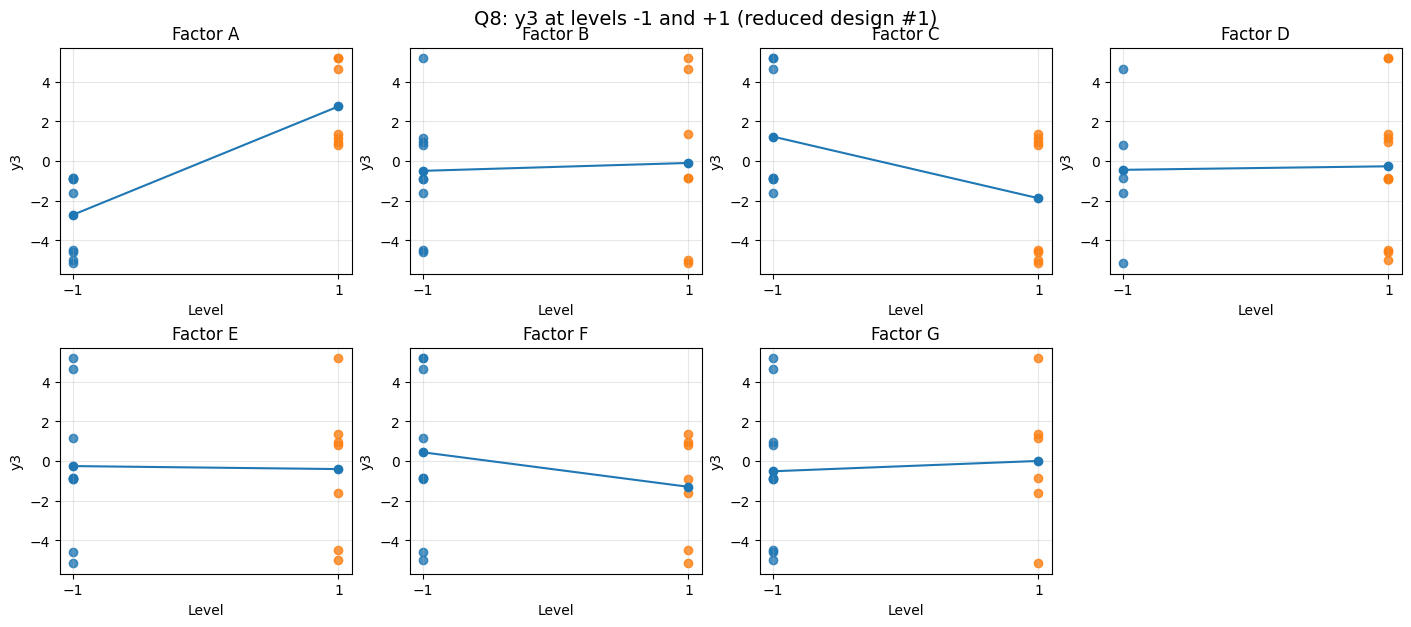

Mean response by factor level (from the reduced design #1):

,mean at -1,mean at +1,difference (+1 - -1)
A,-2.719981,2.744345,5.464326
C,1.224279,-1.882955,-3.107234
F,0.431812,-1.307960,-1.739772
G,-0.524671,-0.003784,0.520887
B,-0.503231,-0.105762,0.397469
D,-0.452187,-0.273498,0.178690
E,-0.263573,-0.413894,-0.150321


In [18]:
# Q8
# Define y3 for the reduced design #1:
# y3 = 3A - 2C + 0.2D - 0.01F/E + noise

sigma = 0.2
noise = np.random.normal(0.0, sigma, size=len(red1))

Acol, Ccol, Dcol, Ecol, Fcol = (red1['A'].values, red1['C'].values, red1['D'].values, red1['E'].values, red1['F'].values)
y3 = 3*Acol - 2*Ccol + 0.2*Dcol - 0.01*(Fcol/Ecol) + noise

red1_y = red1.copy()
red1_y['y3'] = y3

# Plot response at -1 and +1 for each factor
fig, axes = plt.subplots(2, 4, figsize=(14,6), constrained_layout=True)
axes = axes.ravel()

for i, fac in enumerate(factors):
    ax = axes[i]
    gneg = red1_y.loc[red1_y[fac] == -1, 'y3']
    gpos = red1_y.loc[red1_y[fac] == +1, 'y3']
    ax.scatter([-1]*len(gneg), gneg, alpha=0.8)
    ax.scatter([+1]*len(gpos), gpos, alpha=0.8)
    ax.plot([-1, +1], [gneg.mean(), gpos.mean()], marker='o')
    ax.set_xticks([-1, +1])
    ax.set_title(f'Factor {fac}')
    ax.set_xlabel('Level')
    ax.set_ylabel('y3')
    ax.grid(True, alpha=0.3)

# Hide the unused 8th subplot (since 7 factors)
axes[-1].axis('off')

plt.suptitle('Q8: y3 at levels -1 and +1 (reduced design #1)', y=1.02, fontsize=14)
plt.show()

# Brief inference
means = {}
for fac in factors:
    means[fac] = (red1_y.loc[red1_y[fac]==-1,'y3'].mean(),
                  red1_y.loc[red1_y[fac]==+1,'y3'].mean())
df_means = pd.DataFrame(means, index=['mean at -1','mean at +1']).T
df_means['difference (+1 - -1)'] = df_means['mean at +1'] - df_means['mean at -1']

display(Markdown("""Mean response by factor level (from the reduced design #1):"""))
display(df_means.sort_values('difference (+1 - -1)', key=lambda s: s.abs(), ascending=False))


**Inference:**  
Based on the y3 formula, A and C have the highest influence with the rest having low influence.  
Next experiments should focus on confirming the strongest factors (A, C) with a more balanced design and/or adding replication to reduce uncertainty.

In [19]:
# Q9
pvals = []
for fac in factors:
    gneg = red1_y.loc[red1_y[fac]==-1, 'y3'].values
    gpos = red1_y.loc[red1_y[fac]==+1, 'y3'].values
    # one-way ANOVA comparing the two groups
    Fstat, p = stats.f_oneway(gneg, gpos)
    pvals.append((fac, Fstat, p, gpos.mean()-gneg.mean()))

df_p = pd.DataFrame(pvals, columns=['factor','F','p_value','mean_diff (+1 - -1)']).sort_values('p_value')
display(Markdown("""**9. One-way ANOVA for each factor (−1 vs +1):**"""))
display(df_p)


**9. One-way ANOVA for each factor (−1 vs +1):**

,factor,F,p_value,mean_diff (+1 - -1)
0,A,27.649342,0.000121,5.464326
2,C,3.904357,0.068209,-3.107234
5,F,1.010119,0.331930,-1.739772
6,G,0.080897,0.780249,0.520887
1,B,0.049348,0.827410,0.397469
3,D,0.008682,0.927083,0.178690
4,E,0.007037,0.934334,-0.150321


**Comparison:**  
Smaller p-values should generally align with factors that showed the biggest visual separation in Q8 (typically A C).  
Because this is only 16 runs with random noise, borderline p-values can occur, replication and a more structured fractional factorial design would improve reliability.

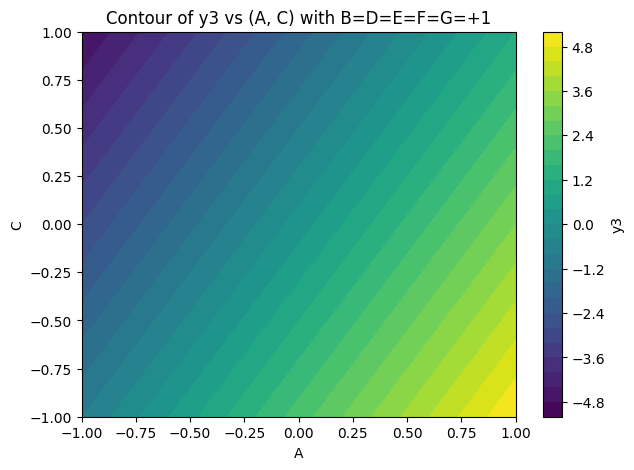

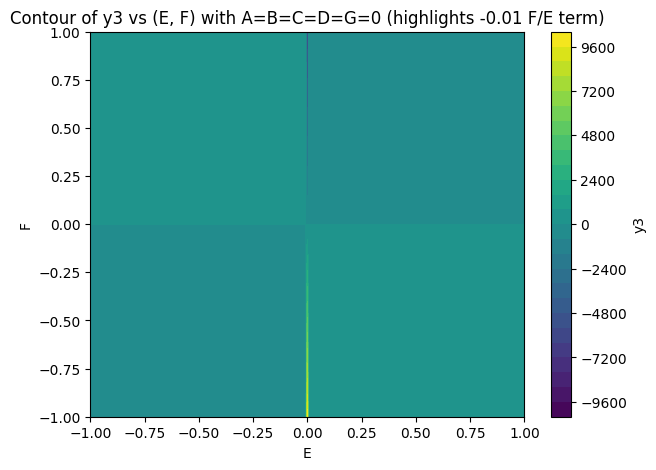

In [20]:
# Q10
# We'll treat factors as continuous in [-1,1] for contour visualization of the model form.
def y3_model(A, B, C, D, E, F, G):
    return 3*A - 2*C + 0.2*D - 0.01*(F/E)

grid = np.linspace(-1, 1, 301)

# Contour plot 1: (A, C) — strongest effects; fix others at +1
AA, CC = np.meshgrid(grid, grid)
B_fix, D_fix, E_fix, F_fix, G_fix = 1, 1, 1, 1, 1
Z1 = y3_model(AA, B_fix, CC, D_fix, E_fix, F_fix, G_fix)

plt.figure(figsize=(7,5))
cs = plt.contourf(AA, CC, Z1, levels=30)
plt.xlabel('A')
plt.ylabel('C')
plt.title('Contour of y3 vs (A, C) with B=D=E=F=G=+1')
plt.colorbar(cs, label='y3')
plt.show()

# Contour plot 2: (E, F) — isolates the ratio term; fix A=C=D=B=G=0 (or +1) and use A=C=0 to highlight term
EE, FF = np.meshgrid(grid, grid)
A_fix, B_fix, C_fix, D_fix, G_fix = 0, 0, 0, 0, 0
# Avoid division by 0: E is in [-1,1], so exclude exactly 0 by nudging
EE_safe = np.where(np.abs(EE) < 1e-6, 1e-6, EE)
Z2 = y3_model(A_fix, B_fix, C_fix, D_fix, EE_safe, FF, G_fix)

plt.figure(figsize=(7,5))
cs2 = plt.contourf(EE, FF, Z2, levels=30)
plt.xlabel('E')
plt.ylabel('F')
plt.title('Contour of y3 vs (E, F) with A=B=C=D=G=0 (highlights -0.01 F/E term)')
plt.colorbar(cs2, label='y3')
plt.show()


**10. Justification (brief):**  
- (A, C) is useful because A and C have the largest coefficients in the model, so this plot shows the dominant response trend while the other factors are fixed at \(+1\).  
- (E, F) is useful because the only nonlinear term is \(-0.01\,F/E\); fixing the other factors to 0 isolates how the ratio structure changes the response.

## Submission Instructions - UPDATED

1. Each question must use **one cell**, with all corresponding outputs displayed directly below it.
2. Before submission, make sure **all outputs are visible** (re-run your code one last time). Submit the notebook as a `.ipynb` file on Quercus. 
3. Grading is based on completion. Completion means that **all questions have visible outputs** and all outputs result from your **own** prompts.
4. Questions requiring explanation must be answered in your own words based on your own analysis.
5. "Briefly" explain means no more than 2 sentences.